# Sentiment Analysis using RoBERTa

---
# Module_1A_EDA


# Sentiment Analysis using RoBERTa

## Module 1A: Exploratory Data Analysis (EDA)

This notebook performs basic EDA on `reviews.csv` and `reviews_by_course.csv`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
reviews = pd.read_csv("reviews.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


## Dataset Overview

In [4]:
def dataset_overview(df, dataset_name):
    print("="*80)
    print(dataset_name)
    print("="*80)
    print("\nShape")
    print(df.shape)
    print("\nColumns")
    print(df.columns.tolist())
    print("\nFirst Five Rows")
    display(df.head())
    print("\nLast Five Rows")
    display(df.tail())
    print("\nRandom Sample")
    display(df.sample(5))
    print("\nDataset Information")
    df.info()
    print("\nStatistical Summary")
    display(df.describe(include="all"))

dataset_overview(reviews,"Reviews Dataset")

Reviews Dataset

Shape
(107018, 3)

Columns
['Id', 'Review', 'Label']

First Five Rows


,Id,Review,Label
0,0,good and interesting,5
1,1,"This class is very helpful to me. Currently, I...",5
2,2,like!Prof and TAs are helpful and the discussi...,5
3,3,Easy to follow and includes a lot basic and im...,5
4,4,Really nice teacher!I could got the point eazl...,4



Last Five Rows


,Id,Review,Label
107013,107013,Trendy topic with talks from expertises in the...,4
107014,107014,"Wonderful! Simple and clear language, good ins...",5
107015,107015,an interesting and fun course. thanks. dr quincy,5
107016,107016,"very broad perspective, up to date information...",4
107017,107017,An informative course on the social and financ...,4



Random Sample


,Id,Review,Label
89047,89047,The course does not have much videos and some ...,3
106173,106173,I found this course easy to follow and informa...,5
52446,52446,"A topic that you've heard pieces of, read head...",5
59838,59838,amazing teaching technique.,5
88139,88139,"the referenced materials are so Amazing , the ...",4



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107018 entries, 0 to 107017
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Id      107018 non-null  int64 
 1   Review  107018 non-null  object
 2   Label   107018 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ MB

Statistical Summary


,Id,Review,Label
count,107018.000000,107018,107018.000000
unique,NaN,100038,NaN
top,NaN,Great course!,NaN
freq,NaN,509,NaN
mean,53508.500000,NaN,4.581145
std,30893.579891,NaN,0.860956
min,0.000000,NaN,1.000000
25%,26754.250000,NaN,4.000000
50%,53508.500000,NaN,5.000000
75%,80262.750000,NaN,5.000000


## Missing Value Analysis

,Column,Missing Values,Percentage
0,Id,0,0.0
1,Review,0,0.0
2,Label,0,0.0


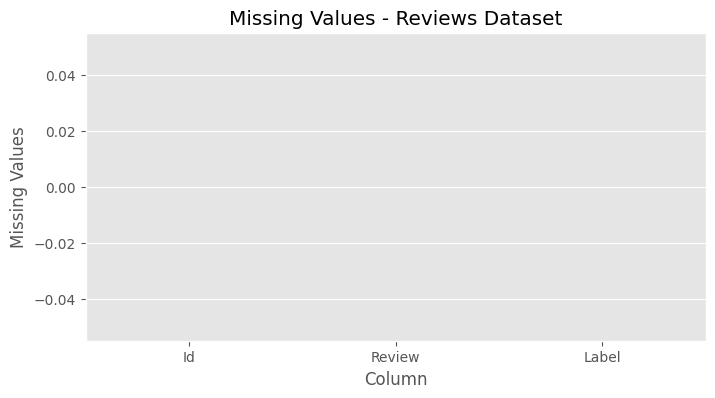

In [5]:
def missing_values(df,name):
    missing=df.isnull().sum()
    report=pd.DataFrame({
        "Column":missing.index,
        "Missing Values":missing.values,
        "Percentage":((missing/len(df))*100).round(2).values
    })
    display(report)
    plt.figure(figsize=(8,4))
    sns.barplot(data=report,x="Column",y="Missing Values")
    plt.title(f"Missing Values - {name}")
    plt.show()

missing_values(reviews,"Reviews Dataset")

## Duplicate Analysis

In [6]:
def duplicate_analysis(df,name):
    print("="*70)
    print(name)
    print("="*70)
    print("Duplicate Rows:",df.duplicated().sum())
    print("Duplicate Reviews:",df.duplicated(subset=["Review"]).sum())

duplicate_analysis(reviews,"Reviews Dataset")

Reviews Dataset
Duplicate Rows: 0
Duplicate Reviews: 6980


## Label Distribution

,Count,Percentage
Label,,
1,2469,2.31
2,2251,2.10
3,5071,4.74
4,18054,16.87
5,79173,73.98


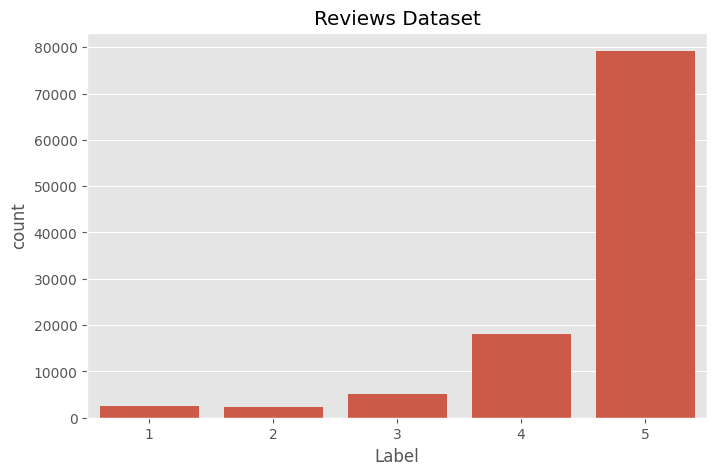

In [7]:
def label_distribution(df,name):
    summary=pd.DataFrame({
        "Count":df["Label"].value_counts().sort_index(),
        "Percentage":(df["Label"].value_counts(normalize=True).sort_index()*100).round(2)
    })
    display(summary)
    plt.figure(figsize=(8,5))
    sns.countplot(data=df,x="Label")
    plt.title(name)
    plt.show()

label_distribution(reviews,"Reviews Dataset")

## Review Length Analysis

,Review Length
count,107018.000000
mean,146.798978
std,188.874884
min,1.000000
25%,44.000000
50%,90.000000
75%,180.000000
max,7766.000000


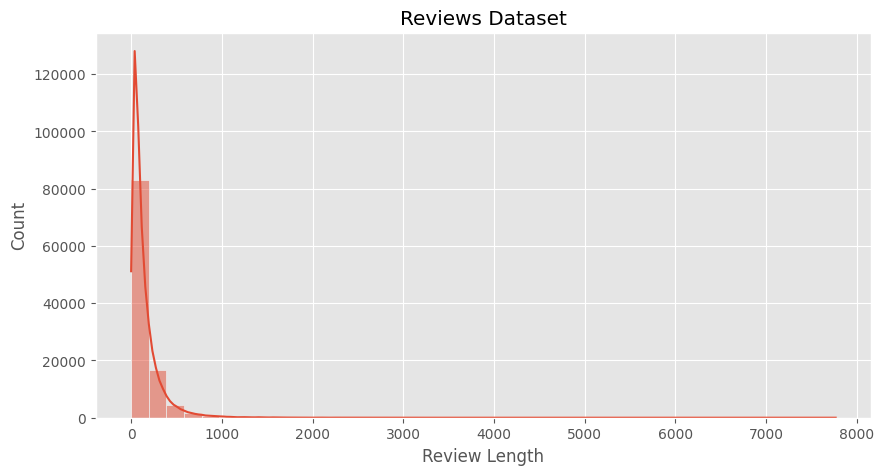

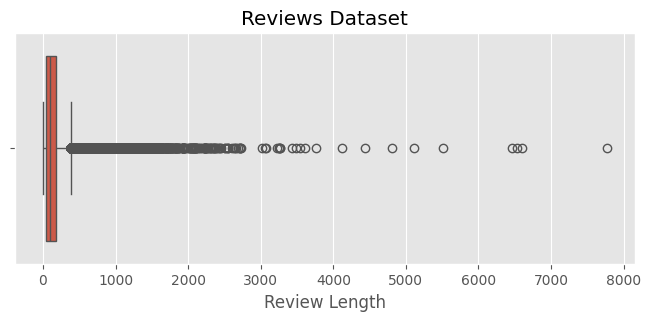

In [8]:
def review_length(df,name):
    df["Review Length"]=df["Review"].astype(str).apply(len)
    display(df["Review Length"].describe())
    plt.figure(figsize=(10,5))
    sns.histplot(df["Review Length"],bins=40,kde=True)
    plt.title(name)
    plt.show()
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df["Review Length"])
    plt.title(name)
    plt.show()

review_length(reviews,"Reviews Dataset")

## Word Count Analysis

,Word Count
count,107018.000000
mean,24.871134
std,32.427376
min,1.000000
25%,7.000000
50%,15.000000
75%,31.000000
max,1338.000000


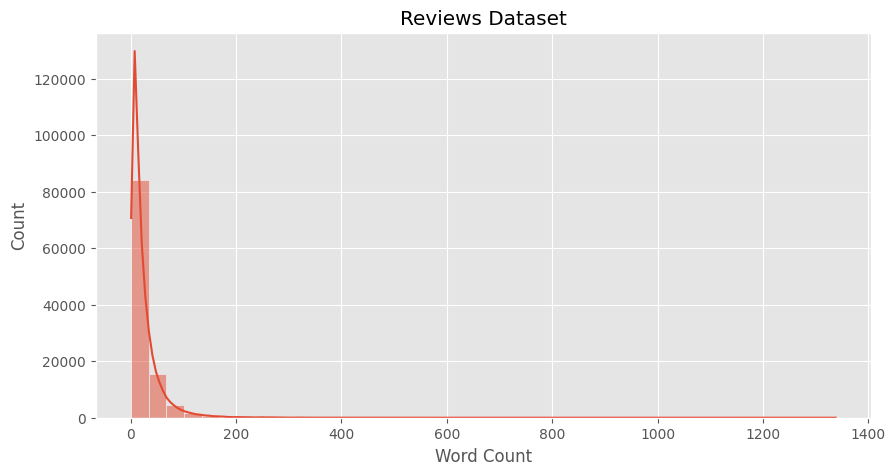

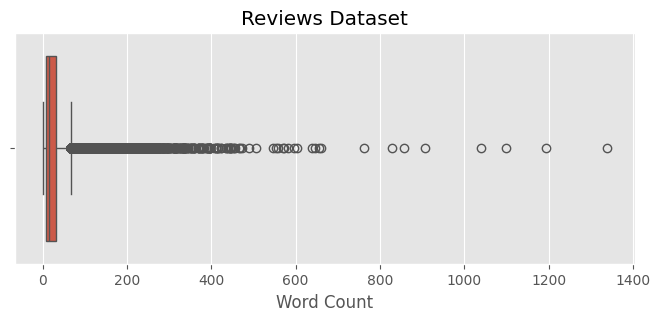

In [9]:
def word_count(df,name):
    df["Word Count"]=df["Review"].astype(str).apply(lambda x: len(x.split()))
    display(df["Word Count"].describe())
    plt.figure(figsize=(10,5))
    sns.histplot(df["Word Count"],bins=40,kde=True)
    plt.title(name)
    plt.show()
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df["Word Count"])
    plt.title(name)
    plt.show()

word_count(reviews,"Reviews Dataset")

## Dataset Summary

In [10]:
def dataset_summary(df,name):
    print("="*80)
    print(name)
    print("="*80)
    print("Total Reviews:",len(df))
    print("Missing Reviews:",df["Review"].isnull().sum())
    print("Duplicate Reviews:",df.duplicated(subset=["Review"]).sum())
    print("Average Review Length:",round(df["Review Length"].mean(),2))
    print("Average Word Count:",round(df["Word Count"].mean(),2))

dataset_summary(reviews,"Reviews Dataset")

Reviews Dataset
Total Reviews: 107018
Missing Reviews: 0
Duplicate Reviews: 6980
Average Review Length: 146.8
Average Word Count: 24.87


---
# Module_1B_Advanced_EDA


# Module 1B: Advanced Exploratory Data Analysis (EDA)

This notebook performs advanced NLP-oriented EDA on both datasets.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import re
import warnings
warnings.filterwarnings("ignore")

reviews=pd.read_csv("reviews.csv")


## Word Cloud

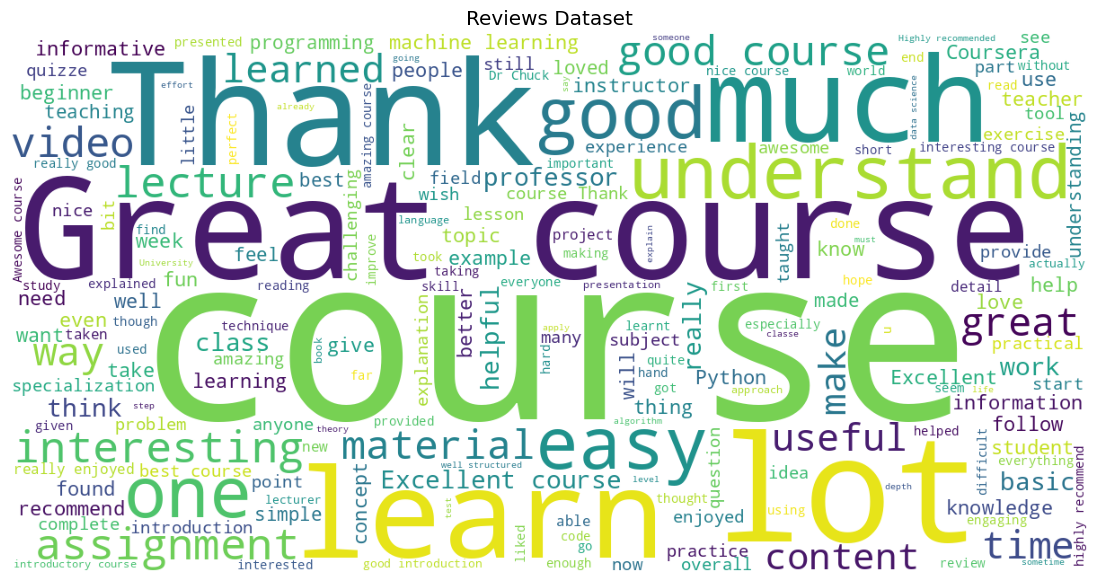

In [12]:
def plot_wordcloud(df,title):
    text=" ".join(df["Review"].fillna("").astype(str))
    wc=WordCloud(width=1200,height=600,background_color="white").generate(text)
    plt.figure(figsize=(14,7))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(reviews,"Reviews Dataset")

## Top 20 Words

,Word,Count
0,the,130856
1,and,91883
2,to,86128
3,course,84641
4,i,71271
5,a,65794
6,of,55335
7,this,44184
8,is,42724
9,it,42654


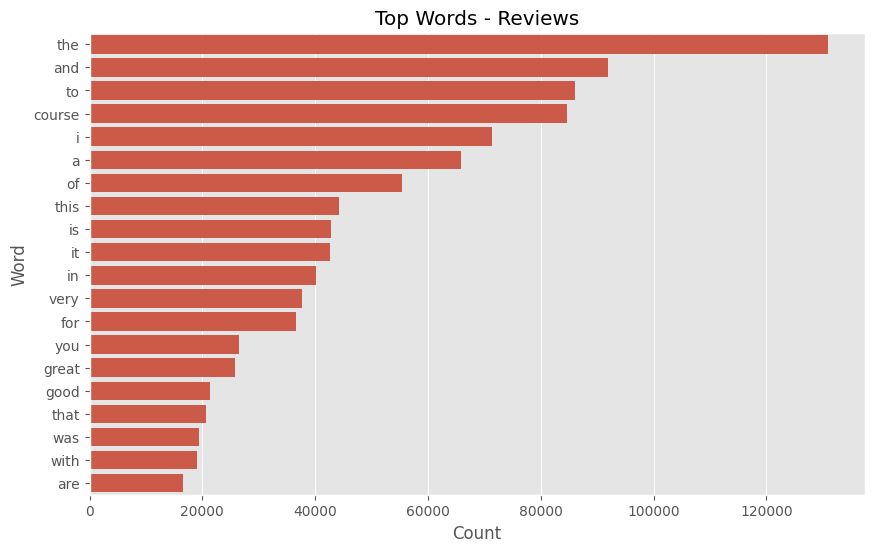

In [13]:
def top_words(df,title):
    words=re.findall(r"\b\w+\b"," ".join(df["Review"].fillna("").astype(str)).lower())
    common=Counter(words).most_common(20)
    top=pd.DataFrame(common,columns=["Word","Count"])
    display(top)
    plt.figure(figsize=(10,6))
    sns.barplot(data=top,x="Count",y="Word")
    plt.title(title)
    plt.show()

top_words(reviews,"Top Words - Reviews")


## Top 20 Bigrams

,Bigram,Count
201962,great course,9416
196710,good course,4987
155367,excellent course,3920
291099,machine learning,3522
266661,learned lot,2246
97387,course really,1988
135999,easy understand,1986
95499,course great,1848
392032,recommend course,1825
95464,course good,1472


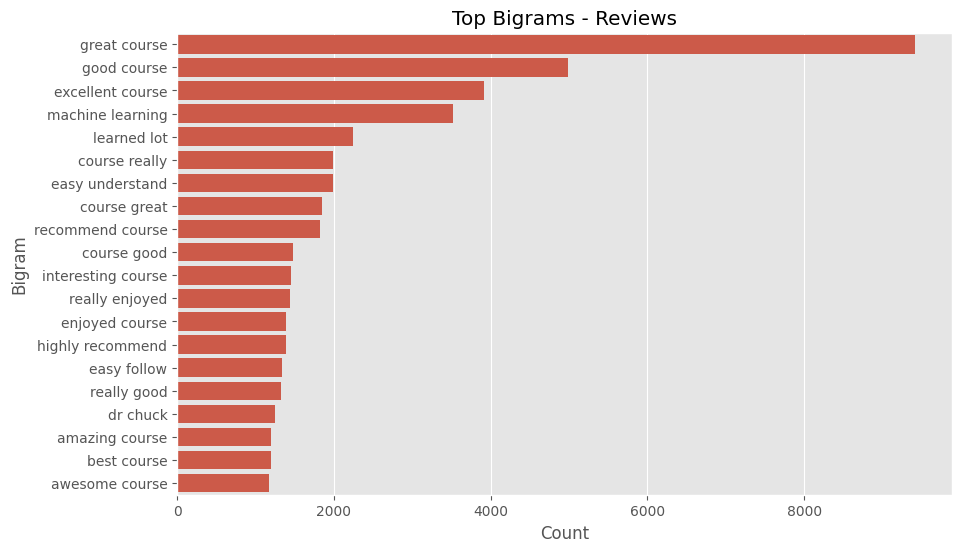

In [14]:
def top_bigrams(df,title):
    vec=CountVectorizer(ngram_range=(2,2),stop_words="english")
    X=vec.fit_transform(df["Review"].fillna("").astype(str))
    counts=X.sum(axis=0).A1
    vocab=vec.get_feature_names_out()
    big=pd.DataFrame({"Bigram":vocab,"Count":counts}).sort_values("Count",ascending=False).head(20)
    display(big)
    plt.figure(figsize=(10,6))
    sns.barplot(data=big,x="Count",y="Bigram")
    plt.title(title)
    plt.show()

top_bigrams(reviews,"Top Bigrams - Reviews")


## Top 20 Trigrams

,Trigram,Count
693511,really enjoyed course,600
395618,highly recommend course,516
167313,course learned lot,475
694455,really good course,372
365908,great course great,368
445434,introduction machine learning,320
482442,learned lot course,297
353856,good introductory course,286
169603,course machine learning,271
369687,great introductory course,252


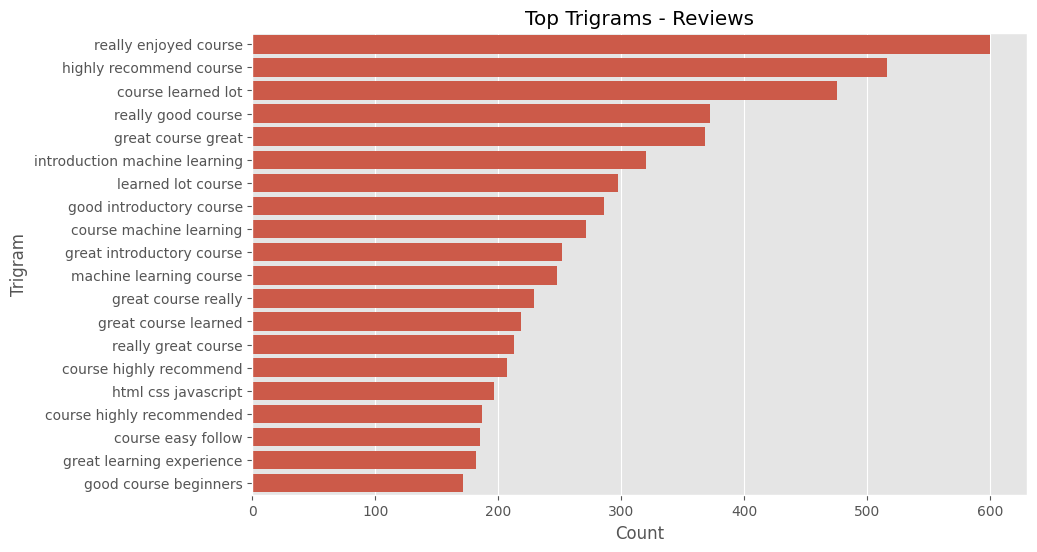

In [15]:
def top_trigrams(df,title):
    vec=CountVectorizer(ngram_range=(3,3),stop_words="english")
    X=vec.fit_transform(df["Review"].fillna("").astype(str))
    counts=X.sum(axis=0).A1
    vocab=vec.get_feature_names_out()
    tri=pd.DataFrame({"Trigram":vocab,"Count":counts}).sort_values("Count",ascending=False).head(20)
    display(tri)
    plt.figure(figsize=(10,6))
    sns.barplot(data=tri,x="Count",y="Trigram")
    plt.title(title)
    plt.show()

top_trigrams(reviews,"Top Trigrams - Reviews")


## Review Length vs Rating

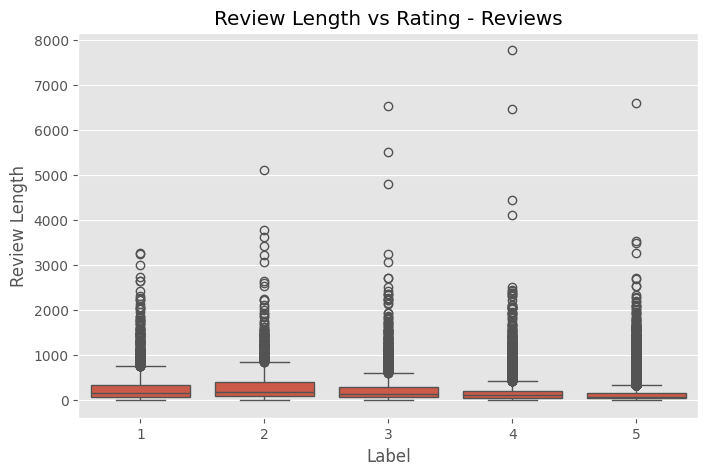

In [16]:
for df,name in [(reviews,"Reviews")]:
    df["Review Length"]=df["Review"].fillna("").astype(str).apply(len)
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df,x="Label",y="Review Length")
    plt.title(f"Review Length vs Rating - {name}")
    plt.show()


## Export EDA Report

In [17]:
def eda_report(df,name):
    report=pd.DataFrame({
        "Metric":[
            "Rows","Columns","Missing Reviews","Duplicate Reviews","Average Review Length"
        ],
        "Value":[
            len(df),
            len(df.columns),
            df["Review"].isnull().sum(),
            df.duplicated(subset=["Review"]).sum(),
            df["Review"].fillna("").astype(str).apply(len).mean()
        ]
    })
    report.to_csv(f"{name}_EDA_Report.csv",index=False)
    display(report)

eda_report(reviews,"Reviews")
print("EDA reports saved.")


,Metric,Value
0,Rows,107018.000000
1,Columns,4.000000
2,Missing Reviews,0.000000
3,Duplicate Reviews,6980.000000
4,Average Review Length,146.798978


EDA reports saved.


---
# Module_2_Preprocessing


# Module 2: Data Preprocessing

This notebook cleans both datasets and prepares them for RoBERTa.

In [18]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

reviews=pd.read_csv("reviews.csv")
print("Datasets Loaded")

Datasets Loaded


## Save Original Statistics

In [19]:
def dataset_statistics(df):
    return {
        "Total Rows":len(df),
        "Missing Reviews":df["Review"].isnull().sum(),
        "Duplicate Reviews":df.duplicated(subset=["Review"]).sum(),
        "Empty Reviews":(df["Review"].fillna("").str.strip()=="").sum()
    }

reviews_before=dataset_statistics(reviews)

## Text Cleaning Function

In [20]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text=str(text)

    text=re.sub(r"<.*?>"," ",text)
    text=re.sub(r"http\S+|www\S+"," ",text)
    text=re.sub(r"\S+@\S+"," ",text)
    text=re.sub(r"\s+"," ",text)

    return text.strip()


## Apply Preprocessing

In [21]:
def preprocess(df):

    df = df.copy()

    # Clean text
    df["Review"] = df["Review"].apply(clean_text)

    # Remove empty reviews
    df = df[df["Review"].str.strip() != ""]

    # Remove reviews with less than 2 words
    df = df[df["Review"].apply(lambda x: len(str(x).split()) >= 2)]

    # Remove duplicate reviews
    df = df.drop_duplicates(subset=["Review"])

    # Remove missing values
    df = df.dropna(subset=["Review"])

    # Ensure string datatype
    df["Review"] = df["Review"].astype(str)

    # Convert ratings to sentiment labels
    df["Label"] = df["Label"].apply(
        lambda x: 0 if x in [1, 2]
        else 1 if x == 3
        else 2
    )

    df.reset_index(drop=True, inplace=True)

    return df


reviews_clean = preprocess(reviews)

print("Preprocessing Completed")

Preprocessing Completed


## Save Cleaned Datasets

In [22]:
reviews_clean.to_csv("reviews_cleaned.csv",index=False)

print("Cleaned datasets saved.")

Cleaned datasets saved.


In [23]:
print("Label Distribution")
print(reviews_clean["Label"].value_counts().sort_index())

print("\nMeaning:")
print("0 = Negative (Ratings 1 & 2)")
print("1 = Neutral (Rating 3)")
print("2 = Positive (Ratings 4 & 5)")

Label Distribution
Label
0     4596
1     4978
2    90276
Name: count, dtype: int64

Meaning:
0 = Negative (Ratings 1 & 2)
1 = Neutral (Rating 3)
2 = Positive (Ratings 4 & 5)


## Preprocessing Report

In [24]:
reviews_after=dataset_statistics(reviews_clean)

def report(before,after,title):

    df=pd.DataFrame({
        "Before":before,
        "After":after
    })

    print(title)

    display(df)

    return df

rep1=report(reviews_before,reviews_after,"Reviews Dataset")

rep1.to_csv("Reviews_Preprocessing_Report.csv")

Reviews Dataset


,Before,After
Total Rows,107018,99850
Missing Reviews,0,0
Duplicate Reviews,6980,0
Empty Reviews,0,0


## Before vs After Visualization

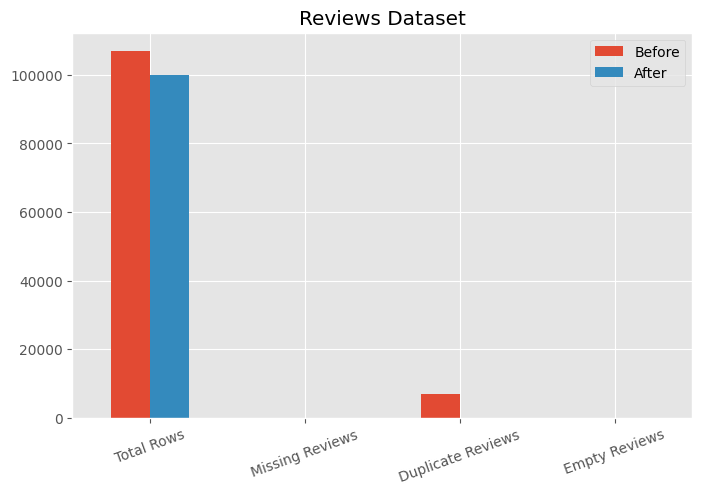

In [25]:
def compare(before,after,title):

    df=pd.DataFrame({
        "Before":before,
        "After":after
    })

    df.plot(kind="bar",figsize=(8,5))
    plt.title(title)
    plt.xticks(rotation=20)
    plt.show()

compare(reviews_before,reviews_after,"Reviews Dataset")


## Final Verification

In [26]:
print("="*60)
print("Reviews Dataset")
print(reviews_clean.shape)
display(reviews_clean.head())

print("\nModule 2 Completed Successfully.")

Reviews Dataset
(99850, 3)


,Id,Review,Label
0,0,good and interesting,2
1,1,"This class is very helpful to me. Currently, I...",2
2,2,like!Prof and TAs are helpful and the discussi...,2
3,3,Easy to follow and includes a lot basic and im...,2
4,4,Really nice teacher!I could got the point eazl...,2



Module 2 Completed Successfully.


---
# Module_3_RoBERTa


# Module 3: RoBERTa Training

Train and evaluate RoBERTa on both cleaned datasets with validation, early stopping, and best-model saving.

In [27]:
import os, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


In [28]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

reviews=pd.read_csv("reviews_cleaned.csv")
tokenizer=RobertaTokenizer.from_pretrained("roberta-base")

cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [29]:
class ReviewDataset(Dataset):
    def __init__(self,texts,labels):
        self.encodings=tokenizer(texts,truncation=True,padding=True,max_length=256)
        self.labels=labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self,idx):
        item={k:torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"]=torch.tensor(self.labels[idx],dtype=torch.long)
        return item


In [33]:
def train_pipeline(df,dataset_name,epochs=4,batch_size=16,patience=2):

    out_dir=f"Outputs/{dataset_name.replace(' ','_')}"
    os.makedirs(out_dir,exist_ok=True)

    X_train,X_val,y_train,y_val=train_test_split(
        df["Review"].astype(str).tolist(),
        df["Label"].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=df["Label"]
    )

    train_loader=DataLoader(ReviewDataset(X_train,y_train),batch_size=batch_size,shuffle=True)
    val_loader=DataLoader(ReviewDataset(X_val,y_val),batch_size=batch_size)

    model=RobertaForSequenceClassification.from_pretrained("roberta-base",num_labels=len(sorted(df["Label"].unique()))).to(device)

    optimizer=AdamW(model.parameters(),lr=2e-5)
    total_steps=len(train_loader)*epochs
    scheduler=get_linear_schedule_with_warmup(optimizer,0,total_steps)

    best_loss=float("inf")
    best_epoch=0
    wait=0
    history=[]

    start=time.time()

    for epoch in range(epochs):

        model.train()
        train_loss=0

        for batch in tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs}"):

            batch={k:v.to(device) for k,v in batch.items()}
            optimizer.zero_grad()
            out=model(**batch)
            loss=out.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss+=loss.item()

        train_loss/=len(train_loader)

        model.eval()

        preds=[]
        actual=[]
        val_loss=0

        with torch.no_grad():
            for batch in val_loader:
                labels=batch["labels"]
                actual.extend(labels.tolist())
                batch={k:v.to(device) for k,v in batch.items()}
                out=model(**batch)
                val_loss+=out.loss.item()
                preds.extend(torch.argmax(out.logits,1).cpu().tolist())

        val_loss/=len(val_loader)

        acc=accuracy_score(actual,preds)
        prec=precision_score(actual,preds,average="weighted")
        rec=recall_score(actual,preds,average="weighted")
        f1=f1_score(actual,preds,average="weighted")

        history.append([epoch+1,train_loss,val_loss,acc,prec,rec,f1])

        print(f"Epoch {epoch+1}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Validation Loss : {val_loss:.4f}")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision : {prec:.4f}")
        print(f"Recall : {rec:.4f}")
        print(f"F1 : {f1:.4f}")

        if val_loss<best_loss:
            best_loss=val_loss
            best_epoch=epoch+1
            wait=0
            model.save_pretrained(os.path.join(out_dir,"best_model"))
            tokenizer.save_pretrained(os.path.join(out_dir,"best_model"))
            print("✔ Best model saved.")
        else:
            wait+=1
            print(f"No improvement. Patience {wait}/{patience}")

        if wait>=patience:
            print("="*60)
            print("EARLY STOPPING ACTIVATED")
            print(f"Validation loss did not improve for {patience} consecutive epochs.")
            print(f"Best Epoch: {best_epoch}")
            print(f"Best Validation Loss: {best_loss:.4f}")
            print("Training stopped to prevent overfitting.")
            print("="*60)
            break

    hist=pd.DataFrame(history,columns=["Epoch","TrainLoss","ValLoss","Accuracy","Precision","Recall","F1"])
    hist.to_csv(os.path.join(out_dir,"training_history.csv"),index=False)

    print(classification_report(actual,preds))
    cm=confusion_matrix(actual,preds)
    ConfusionMatrixDisplay(cm).plot()
    plt.savefig(os.path.join(out_dir,"confusion_matrix.png"))
    plt.show()

    plt.figure()
    plt.plot(hist["Epoch"], hist["TrainLoss"], label="Train")
    plt.plot(hist["Epoch"], hist["ValLoss"], label="Validation")
    plt.legend()
    plt.title("Loss Curve")
    plt.savefig(os.path.join(out_dir, "loss_curve.png"))
    plt.show()

    print(f"Training Time: {time.time()-start:.2f} seconds")

    # Return trained model and tokenizer
    return model, tokenizer


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4:   0%|          | 0/4993 [00:00<?, ?it/s]

Epoch 1
Train Loss : 0.1852
Validation Loss : 0.1685
Accuracy : 0.9353
Precision : 0.9269
Recall : 0.9353
F1 : 0.9276


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✔ Best model saved.


Epoch 2/4:   0%|          | 0/4993 [00:00<?, ?it/s]

Epoch 2
Train Loss : 0.1464
Validation Loss : 0.1771
Accuracy : 0.9372
Precision : 0.9347
Recall : 0.9372
F1 : 0.9353
No improvement. Patience 1/2


Epoch 3/4:   0%|          | 0/4993 [00:00<?, ?it/s]

Epoch 3
Train Loss : 0.1159
Validation Loss : 0.1732
Accuracy : 0.9386
Precision : 0.9342
Recall : 0.9386
F1 : 0.9361
No improvement. Patience 2/2
EARLY STOPPING ACTIVATED
Validation loss did not improve for 2 consecutive epochs.
Best Epoch: 1
Best Validation Loss: 0.1685
Training stopped to prevent overfitting.
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       919
           1       0.46      0.37      0.41       996
           2       0.97      0.98      0.98     18055

    accuracy                           0.94     19970
   macro avg       0.71      0.70      0.70     19970
weighted avg       0.93      0.94      0.94     19970



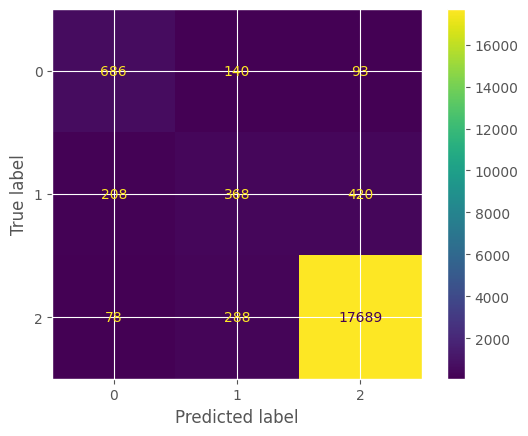

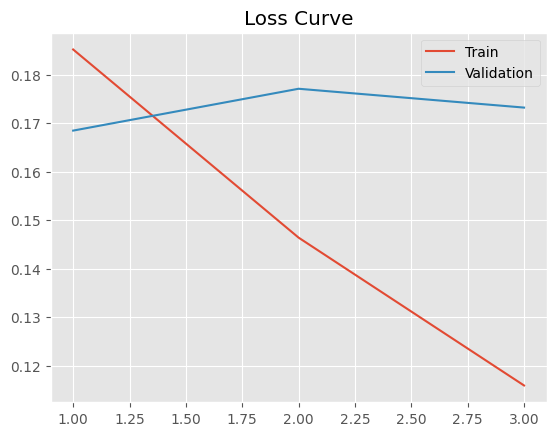

Training Time: 11772.42 seconds


In [34]:
model, tokenizer = train_pipeline(
    reviews,
    "Reviews_Dataset"
)

In [35]:
print(model.config.num_labels)

3


# **LIME**

In [36]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2fa9da7c7d473e3f096df966c9239527a8919d229914b0b46fb379ad6fea7d4d
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [37]:
from lime.lime_text import LimeTextExplainer
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

In [38]:
from lime.lime_text import LimeTextExplainer

class_names = [
    "Negative (0)",
    "Neutral (1)",
    "Positive (2)"
]

explainer = LimeTextExplainer(class_names=class_names)

In [39]:
def predict_proba(texts, model, tokenizer):

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    model.eval()

    with torch.no_grad():

        outputs = model(**inputs)

        probs = torch.softmax(outputs.logits,dim=1)

    return probs.cpu().numpy()

In [40]:
def explain_review(review, model, tokenizer, dataset_name):

    probabilities = predict_proba([review], model, tokenizer)[0]
    predicted_label = int(np.argmax(probabilities))

    explanation = explainer.explain_instance(
        review,
        lambda x: predict_proba(x, model, tokenizer),
        num_features=10,
        labels=[predicted_label]
    )

    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print("\nReview:\n")
    print(review)

    print(f"\nPredicted Sentiment : {class_names[predicted_label]}")

    print("\nPrediction Probabilities\n")

    for i, p in enumerate(probabilities):
        print(f"{class_names[i]:15}: {p:.4f}")

    # Show LIME explanation
    fig = explanation.as_pyplot_figure(label=predicted_label)
    plt.show()

    print("\nImportant Words\n")

    for word, weight in explanation.as_list(label=predicted_label):
        print(f"{word:20} {weight:.4f}")

    explanation.save_to_file(f"{dataset_name}_LIME.html")

    fig.savefig(
        f"{dataset_name}_LIME.png",
        dpi=300,
        bbox_inches="tight"
    )

    print("\n✅ LIME explanation saved successfully.")

In [41]:
probs = predict_proba(
    ["This course is amazing."],
    model,
    tokenizer
)[0]

print(probs)
print(len(probs))

[9.0982991e-05 6.1342283e-04 9.9929559e-01]
3


Custom_Review

Review:


The instructor explained every concept clearly.
The assignments were practical and easy to understand.
I would definitely recommend this course to others.


Predicted Sentiment : Positive (2)

Prediction Probabilities

Negative (0)   : 0.0001
Neutral (1)    : 0.0004
Positive (2)   : 0.9995


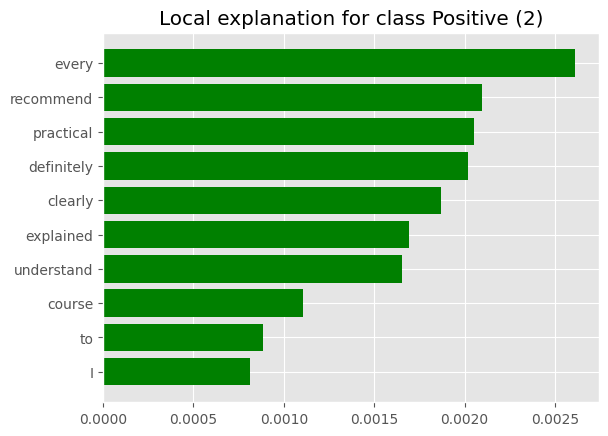


Important Words

every                0.0026
recommend            0.0021
practical            0.0021
definitely           0.0020
clearly              0.0019
explained            0.0017
understand           0.0017
course               0.0011
to                   0.0009
I                    0.0008

✅ LIME explanation saved successfully.


In [42]:
review = """
The instructor explained every concept clearly.
The assignments were practical and easy to understand.
I would definitely recommend this course to others.
"""

explain_review(
    review,
    model,
    tokenizer,
    "Custom_Review"
)

Custom_Review

Review:


The course was really worthless.
I don't feel anything useful in it.
I would not recommend it to anyone.


Predicted Sentiment : Negative (0)

Prediction Probabilities

Negative (0)   : 0.9932
Neutral (1)    : 0.0056
Positive (2)   : 0.0012


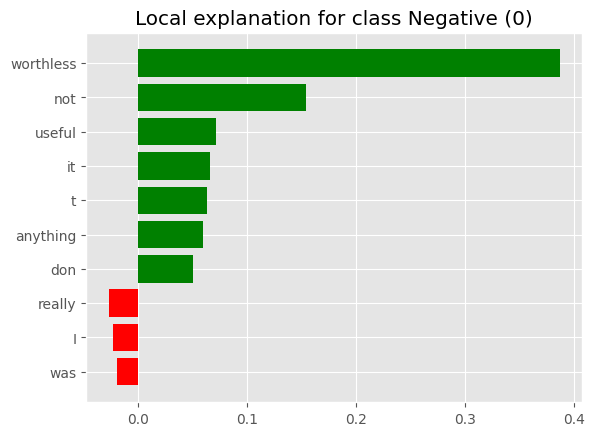


Important Words

worthless            0.3867
not                  0.1538
useful               0.0714
it                   0.0666
t                    0.0632
anything             0.0597
don                  0.0505
really               -0.0266
I                    -0.0226
was                  -0.0188

✅ LIME explanation saved successfully.


In [43]:
review = """
The course was really worthless.
I don't feel anything useful in it.
I would not recommend it to anyone.
"""

explain_review(
    review,
    model,
    tokenizer,
    "Custom_Review"
)